## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [2]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [7]:
def simulazione_lanci(N):
    lanci=np.random.randint(0,2,size=N)
    risultato=(np.sum(lanci)/N)*100
    return(risultato)

In [9]:
grandezza_campioni=np.linspace(10,20000, num=100).astype(int)
percentuali_ottenute = [simulazione_lanci(n) for n in grandezza_campioni]
dati ={
    "Numero_lanci": grandezza_campioni,
    "Percentuale_teste": percentuali_ottenute
}
df = pd.DataFrame(dati)
print(df.head())

   Numero_lanci  Percentuale_teste
0            10          70.000000
1           211          49.763033
2           413          50.363196
3           615          46.666667
4           817          49.326805


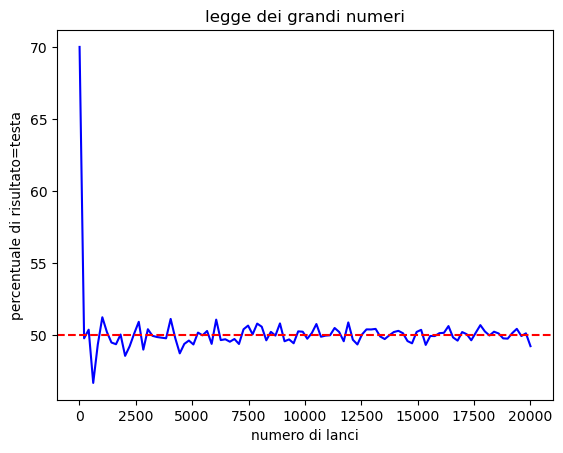

In [13]:
sns.lineplot(data=df, x="Numero_lanci", y="Percentuale_teste", color="blue")
plt.axhline(y=50, color='red', linestyle='--',label="Frequenza empirica")
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [20]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Il dataset ha 891 righe e 12 colonne.
Valori mancanti per colonna: PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64
Le righe duplicate sono: 0
Età media per classi: Pclass
1    37.048118
2    29.866958
3    26.403259
Name: Age, dtype: float64


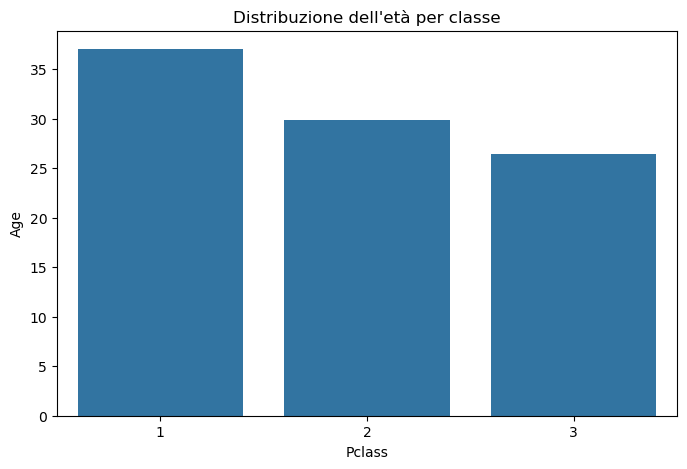

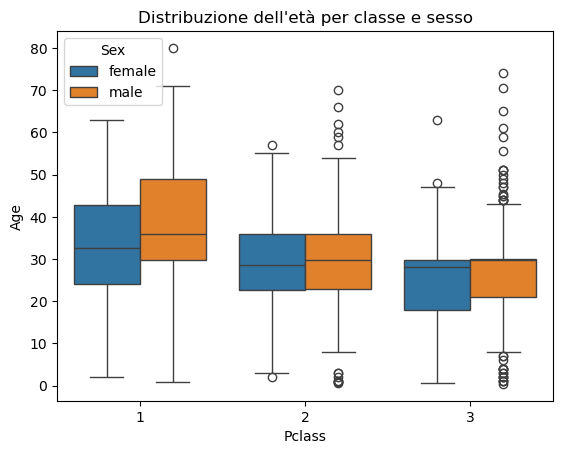

In [34]:
num_col = df.shape[1]
righe = len(df)
print(f"Il dataset ha {righe} righe e {num_col} colonne.")
val_manc = df.isnull().sum()
print("Valori mancanti per colonna:", val_manc)
valore=df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(valore)
righe_dupl = df.duplicated().sum()
print("Le righe duplicate sono:", righe_dupl)
val_medio = df["Age"].mean() 
df["Age"] = df["Age"].fillna(val_medio)
eta_media_classe = df.groupby("Pclass")["Age"].mean()
print("Età media per classi:", eta_media_classe)
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Pclass", y="Age",errorbar=None)
plt.title("Distribuzione dell'età per classe")
plt.show()
sns.boxplot(data=df, x="Pclass", y="Age", hue="Sex")
plt.title("Distribuzione dell'età per classe e sesso")
plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

Distribuzione delle specie: species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
Lunghezza e larghezza media dei petali per specie:             petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026


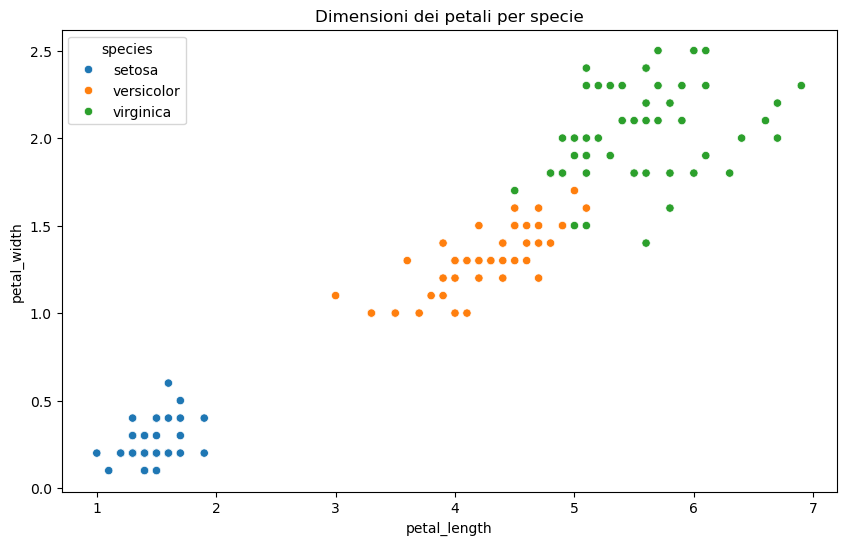

Analisi descrittiva area petalo:             count     mean       std   min     25%     50%    75%    max
species                                                                 
setosa       50.0   0.3656  0.181155  0.11  0.2800   0.300   0.42   0.96
versicolor   50.0   5.7204  1.368403  3.30  4.8600   5.615   6.75   8.64
virginica    50.0  11.2962  2.157412  7.50  9.7175  11.445  12.79  15.87


C:\Users\auror\AppData\Local\Temp\ipykernel_4188\1503059583.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y="petal_area",palette= "Pastel1")


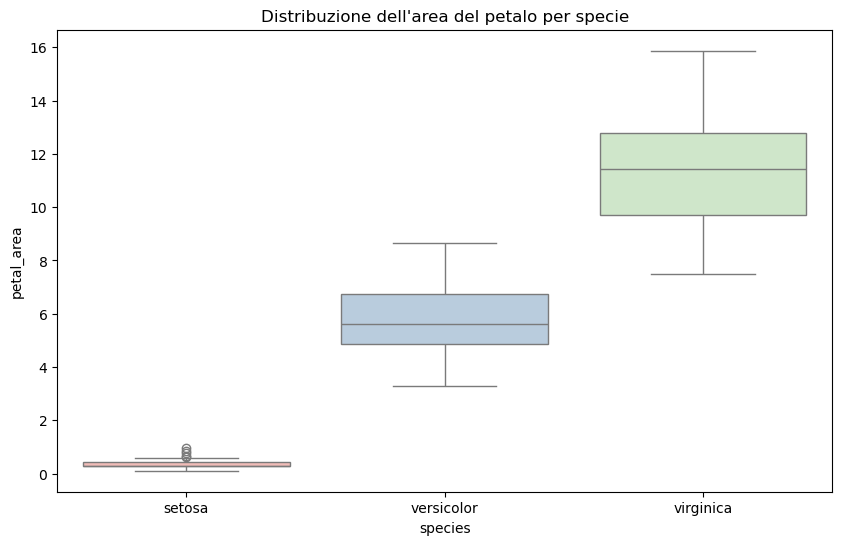

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

conteggio_specie = df["species"].value_counts()
print("Distribuzione delle specie:", conteggio_specie)

dim_pet_per_specie = df.groupby("species")[["petal_length","petal_width"]].mean()
print("Lunghezza e larghezza media dei petali per specie:", dim_pet_per_specie)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species")
plt.title("Dimensioni dei petali per specie")
plt.show()

df["petal_area"]=df["petal_length"]*df["petal_width"]
analisi_area=df.groupby("species")["petal_area"].describe()
print("Analisi descrittiva area petalo:",analisi_area)

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="species", y="petal_area",palette= "Pastel1")
plt.title("Distribuzione dell'area del petalo per specie")
plt.show()